# Funds dosage: distributions and two-part GPS engagement-length analysis

The first sections describe intervention counts and engagement length for the full causal-forest training cohort and its top-benefit 33% subset. The later two-part GPS analysis uses the **whole training cohort** to estimate the engagement-length versus 90-day ED benefit curve.

Run all cells from the repository root or Code folder after the Funds causal-forest workflow has produced its scored outputs. The GPS section writes its own tables and graph to Outputs/Dosage_Funds/Python; existing causal-forest outputs are inputs only.

In [16]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CODE_DIR = Path.cwd() if (Path.cwd() / '_prism_model_utils.py').exists() else Path.cwd() / 'Code'
if not (CODE_DIR / '_prism_model_utils.py').exists():
    raise FileNotFoundError('Run this notebook from the repository root or Code folder.')
sys.path.insert(0, str(CODE_DIR))
from _prism_model_utils import clean_names_simple, split_train_test, to_binary

ROOT = CODE_DIR.parent
RAW_PATH = ROOT / 'DataSets' / 'Funds_combined.csv'
SCORED_DIR = ROOT / 'Outputs' / 'Causal-Forests_Funds' / 'Python'
FULL_PATH = SCORED_DIR / 'causal_forest_scored_output.csv'
TEST_PATH = SCORED_DIR / 'causal_forest_scored_test_output.csv'
for path in (RAW_PATH, FULL_PATH, TEST_PATH):
    if not path.exists():
        raise FileNotFoundError(f'Required Funds input is missing: {path}')
print('Raw data:', RAW_PATH)
print('Causal-forest scores:', FULL_PATH)

Raw data: /home/sagemaker-user/prism_repo/DataSets/Funds_combined.csv
Causal-forest scores: /home/sagemaker-user/prism_repo/Outputs/Causal-Forests_Funds/Python/causal_forest_scored_output.csv


## Reconstruct the exact Funds training cohort

The original workflow uses a 70/30 split stratified by binary treatment and binary 90-day ED outcome, with seed 123. We reproduce it and verify the resulting test row IDs against the saved test output. Because source `member_id` values repeat, the count is aligned by validated source row order and `analysis_row_id`, not by member ID alone.

In [17]:
raw = pd.read_csv(RAW_PATH)
raw.columns = clean_names_simple(raw.columns)
scored = pd.read_csv(FULL_PATH)
saved_test = pd.read_csv(TEST_PATH)

required_raw = {'member_id', 'intervention_flag', 'optout_flag', 'outcome_ed_90d', 'interventioncount', 'engagement_length'}
required_scored = {'analysis_row_id', 'member_id', 'intervention_flag', 'outcome_ed_90d', 'benefit_score'}
assert required_raw.issubset(raw), required_raw - set(raw)
assert required_scored.issubset(scored), required_scored - set(scored)

# Mirror the source workflow's eligibility rule, without refitting the model.
source_treatment = to_binary(raw['intervention_flag']).where(lambda s: s.isin([0.0, 1.0]))
source_optout = to_binary(raw['optout_flag']).where(lambda s: s.isin([0.0, 1.0]))
treated = source_treatment.eq(1.0) & ~source_optout.eq(1.0)
control = source_optout.eq(1.0) & ~source_treatment.eq(1.0)
eligible = treated | control
raw_model = raw.loc[eligible].reset_index(drop=True)
expected_treatment = np.select([treated, control], [1.0, 0.0], default=np.nan)[eligible.to_numpy()]
expected_outcome = (pd.to_numeric(raw['outcome_ed_90d'], errors='coerce').fillna(0) > 0).astype(float)[eligible].to_numpy()

assert len(raw_model) == len(scored), 'Source data and scored file have different model-cohort sizes.'
assert scored['analysis_row_id'].tolist() == list(range(len(scored))), 'Scored source-row order changed.'
assert raw_model['member_id'].astype(str).tolist() == scored['member_id'].astype(str).tolist(), 'Source/scored member order differs.'
assert np.array_equal(expected_treatment, scored['intervention_flag'].to_numpy()), 'Treatment alignment failed.'
assert np.array_equal(expected_outcome, scored['outcome_ed_90d'].to_numpy()), 'Outcome alignment failed.'
assert scored['benefit_score'].notna().all(), 'Some modeled rows lack benefit scores.'

scored['intervention_count'] = pd.to_numeric(raw_model['interventioncount'], errors='coerce').to_numpy()
scored['engagement_length'] = pd.to_numeric(
    raw_model['engagement_length'].replace({'NA': np.nan}), errors='coerce'
).to_numpy()
valid_counts = scored['intervention_count'].dropna()
assert (valid_counts >= 0).all() and (valid_counts % 1 == 0).all(), 'Expected nonnegative integer intervention counts.'

train, reconstructed_test = split_train_test(
    scored, train_fraction=0.70, seed=123,
    stratify_columns=['intervention_flag', 'outcome_ed_90d'],
)
assert reconstructed_test['analysis_row_id'].tolist() == saved_test['analysis_row_id'].tolist(), 'Reconstructed split does not match saved Funds test rows.'
assert len(train) + len(reconstructed_test) == len(scored)
print(f'Exact split verified: {len(train):,} training rows and {len(reconstructed_test):,} test rows.')

Exact split verified: 4,452 training rows and 1,908 test rows.


## Group 1: entire training set

Missing count values have their own row; they are **not** recoded to zero. Percentages use all rows in the named group as the denominator. Summary statistics use only non-missing counts. `Range width` is maximum minus minimum.

Entire Funds training set: 4,452 rows; 1,378 missing intervention counts.


,total_people,nonmissing_counts,missing_counts,mean,minimum,maximum,observed_range,range_width
0,4452,3074,1378,10.19,0.0,71.0,0–71,71.0


,intervention_count,people,percent_of_group
0,0,762,17.12
1,1,11,0.25
2,2,40,0.90
3,3,59,1.33
4,4,87,1.95
5,5,101,2.27
6,6,138,3.10
7,7,156,3.50
8,8,135,3.03
9,9,147,3.30


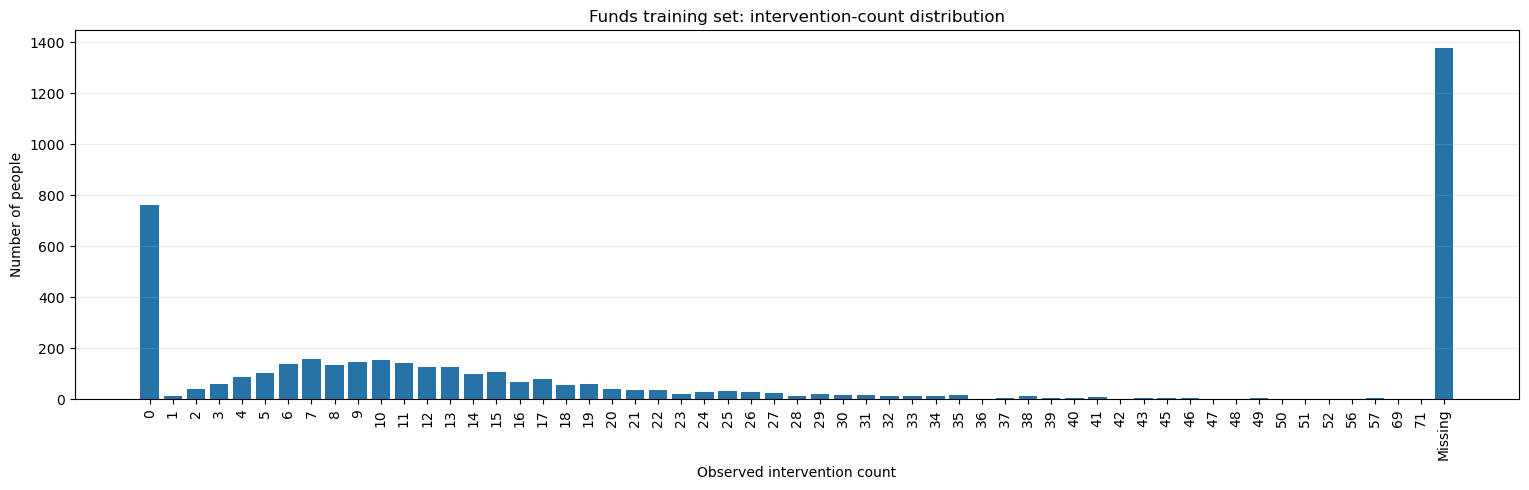

In [18]:
def count_distribution(frame):
    counts = frame['intervention_count'].value_counts(dropna=False).sort_index()
    labels = ['Missing' if pd.isna(value) else str(int(value)) for value in counts.index]
    return pd.DataFrame({
        'intervention_count': labels,
        'people': counts.to_numpy(dtype=int),
        'percent_of_group': (100 * counts.to_numpy() / len(frame)).round(2),
    })

def count_summary(frame):
    observed = frame['intervention_count'].dropna()
    minimum = observed.min() if not observed.empty else np.nan
    maximum = observed.max() if not observed.empty else np.nan
    return pd.DataFrame([{
        'total_people': len(frame),
        'nonmissing_counts': len(observed),
        'missing_counts': len(frame) - len(observed),
        'mean': round(observed.mean(), 2),
        'minimum': minimum,
        'maximum': maximum,
        'observed_range': f'{int(minimum)}–{int(maximum)}' if not observed.empty else 'N/A',
        'range_width': maximum - minimum,
    }])

def plot_distribution(distribution, title):
    fig, ax = plt.subplots(figsize=(max(12, 0.27 * len(distribution)), 5))
    ax.bar(distribution['intervention_count'], distribution['people'], color='#2673a8')
    ax.set(title=title, xlabel='Observed intervention count', ylabel='Number of people')
    ax.tick_params(axis='x', labelrotation=90)
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    plt.show()

full_train_dist = count_distribution(train)
print(f'Entire Funds training set: {len(train):,} rows; {train.intervention_count.isna().sum():,} missing intervention counts.')
display(count_summary(train))
display(full_train_dist)
plot_distribution(full_train_dist, 'Funds training set: intervention-count distribution')

## Group 2: highest-benefit 33% of the training set

Rank only training rows by the existing causal-forest `benefit_score` (larger means greater predicted ED reduction under binary treatment). Select `ceil(0.33 × training rows)`; use `analysis_row_id` to break exact score ties reproducibly. This is a subset of Group 1, not a separately fitted dosage model.

Highest-benefit training group: 1,470 of 4,452 rows (33.02%); 416 missing intervention counts.


,total_people,nonmissing_counts,missing_counts,mean,minimum,maximum,observed_range,range_width
0,1470,1054,416,10.65,0.0,57.0,0–57,57.0


,intervention_count,people,percent_of_group
0,0,228,15.51
1,1,2,0.14
2,2,17,1.16
3,3,20,1.36
4,4,32,2.18
5,5,39,2.65
6,6,54,3.67
7,7,50,3.40
8,8,44,2.99
9,9,48,3.27


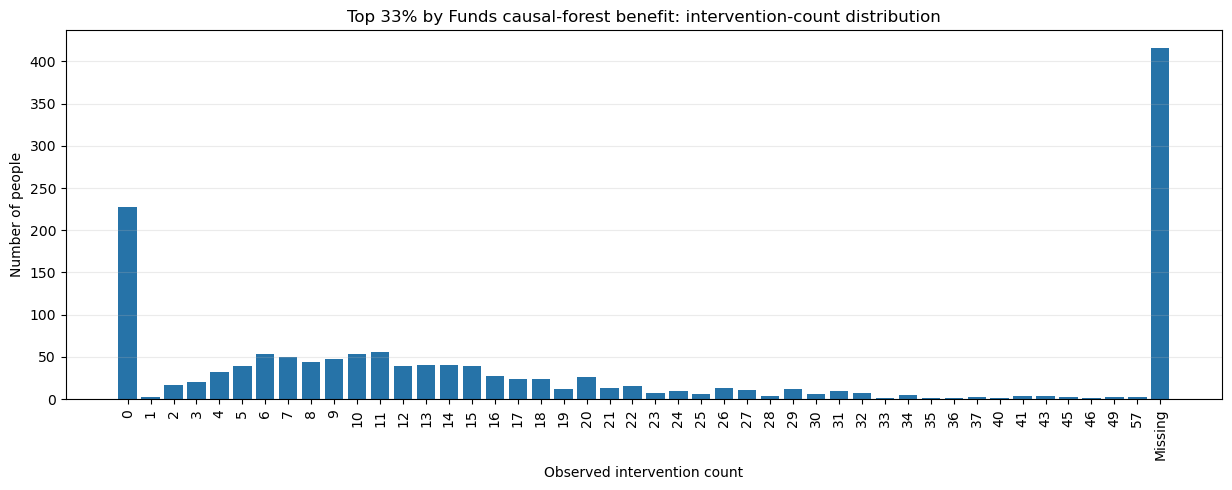

In [19]:
top_n = int(np.ceil(0.33 * len(train)))
high_benefit = train.sort_values(
    ['benefit_score', 'analysis_row_id'], ascending=[False, True], kind='stable'
).head(top_n).copy()
assert high_benefit['analysis_row_id'].isin(train['analysis_row_id']).all()
assert len(high_benefit) == top_n
high_benefit_dist = count_distribution(high_benefit)
print(f'Highest-benefit training group: {len(high_benefit):,} of {len(train):,} rows ({100 * len(high_benefit) / len(train):.2f}%); {high_benefit.intervention_count.isna().sum():,} missing intervention counts.')
display(count_summary(high_benefit))
display(high_benefit_dist)
plot_distribution(high_benefit_dist, 'Top 33% by Funds causal-forest benefit: intervention-count distribution')

## Engagement-length distribution and summary statistics

This section uses the same two training groups as the intervention-count analysis. Engagement length is treated as days. The buckets are `0`, `1–30`, `31–60`, `61–90`, `91–180`, `181–365`, and `>365` days. Missing values and negative values are shown separately; negative values are treated as invalid for summary statistics rather than silently included.

Entire Funds training set: 4,452 rows


,total_people,nonmissing_values,missing_values,invalid_negative_values,valid_observed_values,mean_days,median_days,minimum_days,maximum_days,observed_range_days,range_width_days
0,4452,2966,1486,1,2965,134.95,173.0,0.0,411.0,0–411,411.0


,engagement_length_bucket,people,percent_of_group
0,Invalid (<0),1,0.02
1,0 days,849,19.07
2,1–30 days,6,0.13
3,31–60 days,16,0.36
4,61–90 days,76,1.71
5,91–180 days,846,19.00
6,181–365 days,1151,25.85
7,>365 days,21,0.47
8,Missing,1486,33.38


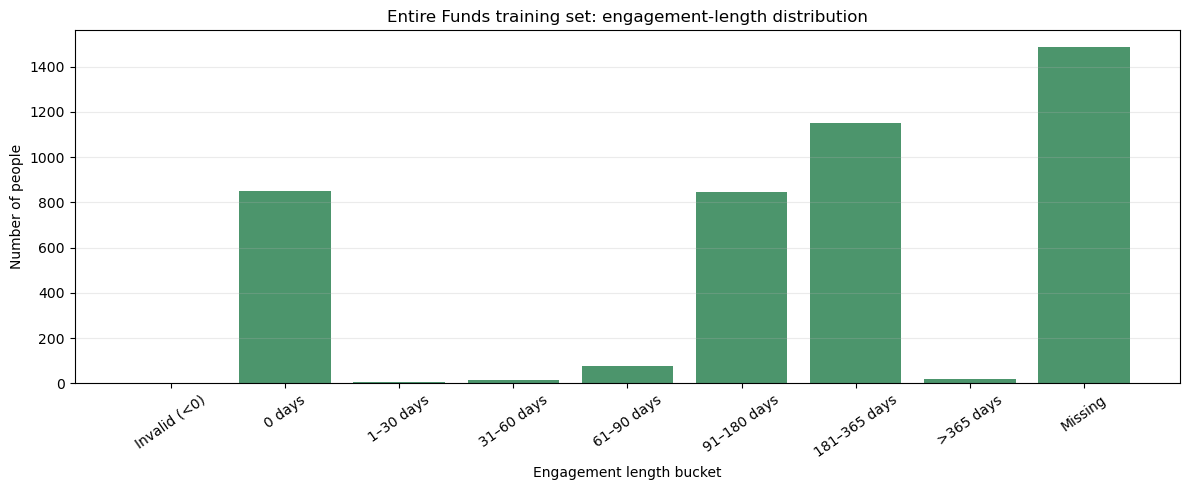

Highest-benefit training group: 1,470 rows


,total_people,nonmissing_values,missing_values,invalid_negative_values,valid_observed_values,mean_days,median_days,minimum_days,maximum_days,observed_range_days,range_width_days
0,1470,1015,455,0,1015,142.32,174.0,0.0,401.0,0–401,401.0


,engagement_length_bucket,people,percent_of_group
0,Invalid (<0),0,0.00
1,0 days,248,16.87
2,1–30 days,5,0.34
3,31–60 days,5,0.34
4,61–90 days,39,2.65
5,91–180 days,302,20.54
6,181–365 days,407,27.69
7,>365 days,9,0.61
8,Missing,455,30.95


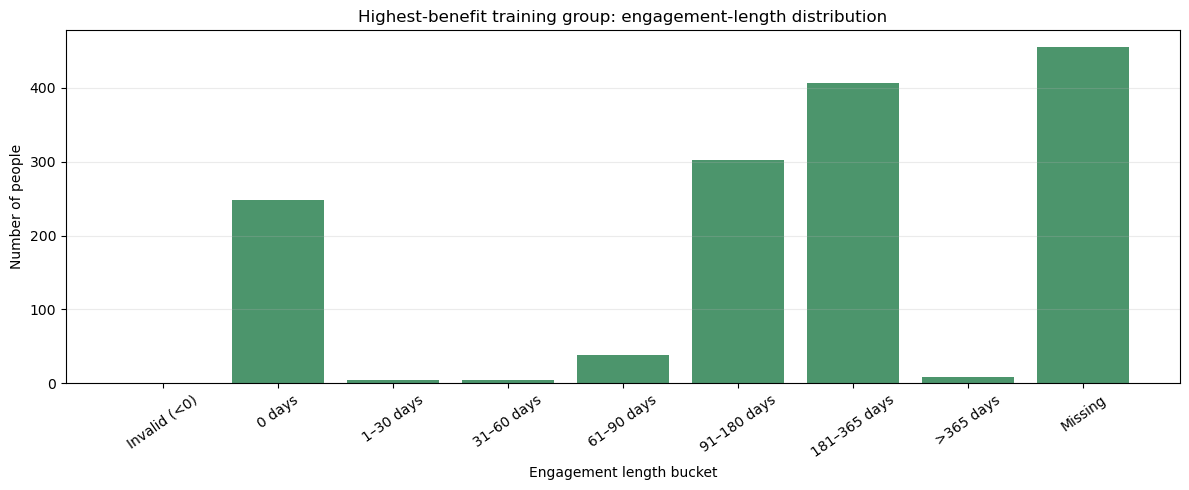

In [20]:
ENGAGEMENT_BUCKETS = ['Invalid (<0)', '0 days', '1–30 days', '31–60 days', '61–90 days', '91–180 days', '181–365 days', '>365 days', 'Missing']

def engagement_length_distribution(frame):
    values = pd.to_numeric(frame['engagement_length'], errors='coerce')
    bucket = pd.Series(pd.NA, index=frame.index, dtype='object')
    bucket.loc[values.isna()] = 'Missing'
    bucket.loc[values.lt(0)] = 'Invalid (<0)'
    bucket.loc[values.eq(0)] = '0 days'
    bucket.loc[values.gt(0) & values.le(30)] = '1–30 days'
    bucket.loc[values.gt(30) & values.le(60)] = '31–60 days'
    bucket.loc[values.gt(60) & values.le(90)] = '61–90 days'
    bucket.loc[values.gt(90) & values.le(180)] = '91–180 days'
    bucket.loc[values.gt(180) & values.le(365)] = '181–365 days'
    bucket.loc[values.gt(365)] = '>365 days'
    counts = bucket.value_counts().reindex(ENGAGEMENT_BUCKETS, fill_value=0)
    return pd.DataFrame({'engagement_length_bucket': counts.index, 'people': counts.to_numpy(dtype=int), 'percent_of_group': (100 * counts.to_numpy() / len(frame)).round(2)})

def engagement_length_summary(frame):
    values = pd.to_numeric(frame['engagement_length'], errors='coerce')
    observed = values.loc[values.ge(0)].dropna()
    minimum = observed.min() if not observed.empty else np.nan
    maximum = observed.max() if not observed.empty else np.nan
    return pd.DataFrame([{
        'total_people': len(frame),
        'nonmissing_values': int(values.notna().sum()),
        'missing_values': int(values.isna().sum()),
        'invalid_negative_values': int(values.lt(0).sum()),
        'valid_observed_values': len(observed),
        'mean_days': round(observed.mean(), 2) if not observed.empty else np.nan,
        'median_days': round(observed.median(), 2) if not observed.empty else np.nan,
        'minimum_days': minimum,
        'maximum_days': maximum,
        'observed_range_days': f'{minimum:g}–{maximum:g}' if not observed.empty else 'N/A',
        'range_width_days': maximum - minimum if not observed.empty else np.nan,
    }])

def plot_engagement_length_distribution(distribution, title):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(distribution['engagement_length_bucket'], distribution['people'], color='#4c956c')
    ax.set(title=title, xlabel='Engagement length bucket', ylabel='Number of people')
    ax.tick_params(axis='x', labelrotation=35)
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    plt.show()

for group_name, group_frame in [('Entire Funds training set', train), ('Highest-benefit training group', high_benefit)]:
    distribution = engagement_length_distribution(group_frame)
    print(f'{group_name}: {len(group_frame):,} rows')
    display(engagement_length_summary(group_frame))
    display(distribution)
    plot_engagement_length_distribution(distribution, f'{group_name}: engagement-length distribution')

## Two-part GPS: engagement length versus benefit (full training cohort)

This analysis targets **all rows in the verified Funds training split**, including controls.
The top-benefit subset above is descriptive only and is not used to select this analysis population.
The response is any recorded ED event within 90 days, matching the existing Funds outcome definition.
Benefit at dose \(a\) is \(100[\widehat\mu(0)-\widehat\mu(a)]\), in **percentage points**; positive values indicate lower estimated ED risk.

**Method and R equivalence.** This is a Python implementation of the CausalGPS continuous matching
calculation, extended to an exposure with a separate zero mass. CausalGPS itself does not implement
this two-part procedure, so this is **not an exact port of an existing two-part R estimator**.
We inspected [CausalGPS source commit 283eb329](https://github.com/NSAPH-Software/CausalGPS/tree/283eb3299b81fb91fd56e6f426c2a1d0f699bf67).

| Component | Implementation here and relationship to R |
|---|---|
| Treatment occurrence | Logistic model \(p_i=P(D=1\mid X_i)\); added for the zero mass |
| Positive duration | Ridge mean model for log-days plus normal residual SD (ddof=1, as in R sd); lognormal density on the **days** scale includes the \(1/a\) Jacobian |
| Positive-dose GPS | \(g(a,X_i)=p_i f_+(a\mid D=1,X_i)\); added two-part structure |
| Zero-dose matching | Exact controls only, matched on \(1-p_i\); zero probabilities are never scaled together with positive densities |
| Positive matching | R's min–max scaling, L1 distance, full-width delta_n (radius delta_n/2), one nearest donor per template per target, with replacement |
| Pseudo-population | Sum donor reuse counts over the positive exposure grid, as in create_matching() |
| Smooth positive curve | Match-count-weighted Gaussian local-linear regression, corresponding to kernel_appr="locpol" with degree 1 and a single supplied bandwidth |
| Basic checks | Donor counts, GPS support, donor/member effective counts, and per-dose covariate balance against the fixed full-training target |
| Differences | Added zero mass and lognormal density; fixed Python nuisance learners rather than R SuperLearner; SMD diagnostics rather than R polyserial/Spearman checks; no automatic trimming or tuning |

The positive-dose mean and residual-SD construction follows the normal branch of
[estimate_gps.R](https://github.com/NSAPH-Software/CausalGPS/blob/283eb3299b81fb91fd56e6f426c2a1d0f699bf67/R/estimate_gps.R)
on log-days. Matching follows
[matching_fn.R](https://github.com/NSAPH-Software/CausalGPS/blob/283eb3299b81fb91fd56e6f426c2a1d0f699bf67/R/matching_fn.R);
smoothing follows
[smooth_erf.R](https://github.com/NSAPH-Software/CausalGPS/blob/283eb3299b81fb91fd56e6f426c2a1d0f699bf67/R/smooth_erf.R).
Neither R execution nor end-to-end numerical parity is claimed. The
[semi-continuous exposure paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC10583890/)
motivates separating exposure occurrence and amount, but its published regression/stratification
estimator is not this matching extension.

**Interpretation for this dataset.** The user reports that the 90-day ED outcome window starts
90 days after the first engagement day (approximately days 90–180). Full observed engagement length
often exceeds 90 days and therefore can overlap or extend beyond the outcome window. This curve
can reflect reverse causation or survival/follow-up differences; a static GPS cannot repair that.
The full-duration graph remains exploratory. A causal redesign would measure exposure before day 90
and define comparable time zero for controls, or explicitly model time-varying engagement.
Repeated member IDs remain separate source rows to preserve the requested cohort; the estimand is
row/episode-weighted, not one equally weighted observation per unique member. Matching outcomes are
noisy donor contributions to a population average, not validated individual benefit predictions.
No confidence intervals are supplied: an ordinary bootstrap of these nearest-neighbor matches would
not reproduce the paper's inference method.

In [21]:
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
import json
import warnings

# Edit these before rerunning this section. No R installation is needed.
GPS_CONFIG = {
    'seed': 123,
    'delta_n_days': 60.0,       # R implementation: FULL width -> +/-30 days
    'scale': 0.5,              # weight on scaled GPS; remaining weight on days
    'positive_grid_days': list(range(30, 391, 30)),
    'smoothing_bandwidth_days': 30.0,  # equivalent to a singleton R bw_seq
    'logistic_C': 1.0,
    'ridge_alpha': 10.0,
    'minimum_candidate_donors': 30,
    'minimum_member_ess': 30.0,
    'maximum_outside_gps_fraction': 0.10,
    'maximum_abs_smd': 0.10,
    'outcome_window_confirmed_after_exposure': False,  # full duration can exceed day 90
    'outcome_start_days_after_engagement': 90,
    'outcome_window_length_days': 90,
    'write_outputs': True,
}
GPS_OUTPUT_DIR = ROOT / 'Outputs' / 'Dosage_Funds' / 'Python'
assert GPS_CONFIG['delta_n_days'] > 0
assert 0 <= GPS_CONFIG['scale'] <= 1
assert GPS_CONFIG['smoothing_bandwidth_days'] > 0
print('Population: all training rows. Positive benefit = lower estimated ED risk versus zero exposure.')
print('Matching parameters:', {k: GPS_CONFIG[k] for k in ['delta_n_days', 'scale', 'smoothing_bandwidth_days']})

Population: all training rows. Positive benefit = lower estimated ED risk versus zero exposure.
Matching parameters: {'delta_n_days': 60.0, 'scale': 0.5, 'smoothing_bandwidth_days': 30.0}


### Exposure and outcome rules

* Confirmed controls with missing or zero source duration are assigned **structural zero** for this model.
  The raw duration is retained. This assumes the opt-out definition really means no engagement.
* Treated rows with positive finite duration are eligible positive-dose donors.
* Treated zero, missing, negative, or nonfinite durations remain **target templates** and contribute to
  the treatment-occurrence model, but cannot supply positive-dose outcomes or fit the duration model.
  Same-day treatment can have zero elapsed days; these records are not automatically controls.
  Program duration (ProgramEnd minus ProgramStart) is not substituted for engagement duration.
* Any control with positive/invalid source duration is flagged and excluded from the donor pool.
* The previous workflow's missing-outcome-as-zero rule is explicitly retained and counted.
  This requires missing records to mean no recorded ED event, not unknown follow-up.
* The same complete target cohort is used at every dose. No dose-specific trimming silently changes
  the population. Poorly supported targets are flagged.

In [22]:
# Re-align by verified source-row IDs; never join repeated member IDs.
gps_train = raw_model.iloc[train['analysis_row_id'].to_numpy(dtype=int)].copy().reset_index(drop=True)
gps_train.insert(0, 'analysis_row_id', train['analysis_row_id'].to_numpy(dtype=int))
assert gps_train['member_id'].astype(str).tolist() == train['member_id'].astype(str).tolist()
assert set(gps_train['analysis_row_id']).isdisjoint(saved_test['analysis_row_id'])
gps_train['source_intervention_flag'] = gps_train['intervention_flag']
gps_train['received_treatment'] = train['intervention_flag'].to_numpy(dtype=int)
gps_train['raw_engagement_length'] = pd.to_numeric(gps_train['engagement_length'], errors='coerce')

raw_days = gps_train['raw_engagement_length'].to_numpy(dtype=float)
received = gps_train['received_treatment'].to_numpy(dtype=int)
positive_donor = (received == 1) & np.isfinite(raw_days) & (raw_days > 0)
zero_donor = (received == 0) & (np.isnan(raw_days) | (raw_days == 0))
gps_train['dose_status'] = np.select(
    [zero_donor & np.isnan(raw_days), zero_donor, positive_donor, received == 1],
    ['control_missing_to_structural_zero', 'control_observed_zero',
     'treated_valid_positive', 'treated_unknown_or_nonpositive_dose'],
    default='control_inconsistent_duration',
)
gps_train['analysis_dose_days'] = np.where(zero_donor, 0.0, np.where(positive_donor, raw_days, np.nan))
raw_ed = pd.to_numeric(gps_train['outcome_ed_90d'], errors='coerce')
if (raw_ed.dropna() < 0).any() or np.isinf(raw_ed.dropna()).any():
    raise ValueError('Invalid ED outcome counts; resolve before modeling.')
gps_train['outcome_missing_filled_zero'] = raw_ed.isna()
gps_train['ed_event_90d'] = (raw_ed.fillna(0) > 0).astype(int)
assert np.array_equal(gps_train['ed_event_90d'], train['outcome_ed_90d'].to_numpy())
assert len(gps_train) == len(train)

exposure_audit = gps_train.groupby(
    ['dose_status', 'received_treatment'], dropna=False
).agg(rows=('analysis_row_id', 'size'), unique_members=('member_id', 'nunique')).reset_index()
display(exposure_audit)
print(f'Target templates: {len(gps_train):,}; zero donors: {zero_donor.sum():,}; positive donors: {positive_donor.sum():,}.')
print(f"Missing outcomes filled with zero: {gps_train['outcome_missing_filled_zero'].sum():,}.")
print(f'Positive-dose donors with duration >90 days: {int((positive_donor & (raw_days > 90)).sum()):,}; temporal overlap is possible.')
print(f"Repeated-member rows beyond first: {gps_train['member_id'].duplicated().sum():,}.")
print('Unknown/invalid-dose templates retained; dose modeling assumes valid-dose donors represent these patients conditional on baseline covariates.')
if zero_donor.sum() < 2 or positive_donor.sum() < 3:
    raise ValueError('Insufficient zero or positive exposure donors.')

,dose_status,received_treatment,rows,unique_members
0,control_missing_to_structural_zero,0,1486,1459
1,control_observed_zero,0,845,845
2,treated_unknown_or_nonpositive_dose,1,5,4
3,treated_valid_positive,1,2116,1519


Target templates: 4,452; zero donors: 2,331; positive donors: 2,116.
Missing outcomes filled with zero: 155.
Positive-dose donors with duration >90 days: 2,018; temporal overlap is possible.
Repeated-member rows beyond first: 1,282.
Unknown/invalid-dose templates retained; dose modeling assumes valid-dose donors represent these patients conditional on baseline covariates.


### Fit the two exposure-assignment components

Only baseline covariates from the Funds workflow are used, with imputation and encoding fit on
training rows. The existing causal-forest benefit score, intervention counts, engagement dates,
post-treatment death information, and all outcomes are excluded from the GPS predictors.
The binary treatment labels and training split are inherited; the causal forest is not refitted.

For positive days \(a\),
\[
\log(A)\mid D=1,X \sim N(m(X),s^2),\qquad
f_+(a\mid X)=\frac{\phi((\log(a)-m(X))/s)}{a s}.
\]
The GPS at zero is \(1-p(X)\); at a positive target it is \(p(X)f_+(a\mid X)\).
Logistic and Ridge regularization are fixed configuration choices, not selected with the outcomes.
This parsimonious working density is an assumption, not evidence that duration is truly lognormal.

In [23]:
NUMERIC_BASELINE = [
    'age', 'dual_elg', 'diabetes_flag', 'chf_flag', 'copd_flag', 'asthma_flag',
    'depression_flag', 'anxiety_flag', 'substance_use_flag', 'ckd_flag', 'bh_flag',
    'htn_flag', 'hyperlipidemia_flag', 'cad_flag', 'financial_strain_flag',
    'food_insecurity_flag', 'housing_instability_flag', 'transportation_barrier_flag',
    'healthliteracy_challenges_flag', 'op_visits_last_6m', 'ed_visits_last_30d',
    'ed_visits_last_6m', 'admits_last_6m', 'observation_stays_last_6m',
    'total_cost_last_6m', 'rx_count_last_6m', 'opioid_flag', 'polypharmacy_flag',
    'current_risk_score', 'percolator_score',
]
CATEGORICAL_BASELINE = ['client_contract', 'gender', 'county', 'state', 'plan_type', 'risk_tier']
baseline_cols = NUMERIC_BASELINE + CATEGORICAL_BASELINE
missing_baseline = sorted(set(baseline_cols) - set(gps_train))
if missing_baseline:
    raise KeyError(f'Required baseline columns missing: {missing_baseline}')

numeric_x = gps_train[NUMERIC_BASELINE].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
numeric_missing = numeric_x.isna().astype(float).add_suffix('__missing')
training_medians = numeric_x.median().fillna(0.0)
numeric_x = numeric_x.fillna(training_medians)
category_x = gps_train[CATEGORICAL_BASELINE].astype('string').fillna('Missing')
category_x['risk_tier'] = (
    pd.to_numeric(gps_train['risk_tier'], errors='coerce')
    .where(lambda s: s.isin([1, 2, 3, 4, 5])).astype('Int64').astype('string').fillna('Missing')
)
encoded_categories = pd.get_dummies(category_x, prefix_sep='__', dtype=float)
gps_covariates = pd.concat([numeric_x, numeric_missing, encoded_categories], axis=1)
gps_covariates = gps_covariates.loc[:, gps_covariates.nunique() > 1].astype(float)
assert np.isfinite(gps_covariates.to_numpy()).all()
scaler = StandardScaler()
gps_x = scaler.fit_transform(gps_covariates)

occurrence_model = LogisticRegression(
    C=GPS_CONFIG['logistic_C'], solver='lbfgs', max_iter=3000,
    random_state=GPS_CONFIG['seed'],
)
occurrence_model.fit(gps_x, received)
p_treated = occurrence_model.predict_proba(gps_x)[:, list(occurrence_model.classes_).index(1)]
# No substantive propensity clipping or trimming: diagnose poor support instead.
if not np.all((p_treated > 0) & (p_treated < 1)):
    raise ValueError('Occurrence model probabilities at 0/1; review separation and regularization.')
duration_model = Ridge(alpha=GPS_CONFIG['ridge_alpha'])
log_days = np.log(raw_days[positive_donor])
duration_model.fit(gps_x[positive_donor], log_days)
predicted_log_days = duration_model.predict(gps_x)
duration_residual_sd = float(np.std(log_days - predicted_log_days[positive_donor], ddof=1))
if not np.isfinite(duration_residual_sd) or duration_residual_sd <= 1e-8:
    raise ValueError('Degenerate dose residual SD; review exposure/model.')

def positive_gps(days, probability, log_mean, log_sd):
    days = np.asarray(days, dtype=float)
    if np.any(days <= 0) or not np.isfinite(days).all():
        raise ValueError('Positive-dose density requires strictly positive finite days.')
    return np.asarray(probability) * norm.pdf(np.log(days), loc=log_mean, scale=log_sd) / days

gps_train['p_treated'] = p_treated
gps_train['predicted_log_days'] = predicted_log_days
gps_train['gps_at_observed_exposure'] = np.nan
gps_train.loc[zero_donor, 'gps_at_observed_exposure'] = 1 - p_treated[zero_donor]
gps_train.loc[positive_donor, 'gps_at_observed_exposure'] = positive_gps(
    raw_days[positive_donor], p_treated[positive_donor],
    predicted_log_days[positive_donor], duration_residual_sd,
)
print(f'Baseline encoded features: {gps_x.shape[1]}; residual SD on log-days: {duration_residual_sd:.3f}.')
display(gps_train.groupby('received_treatment')['p_treated'].agg(['count', 'min', 'median', 'max']))

Baseline encoded features: 348; residual SD on log-days: 0.294.


,count,min,median,max
received_treatment,,,,
0,2331,0.000025,0.366565,0.932720
1,2121,0.077353,0.570994,0.999999


### Match each training template at each target duration

For positive targets, donor GPS values are evaluated at each donor's **observed** dose; the template
GPS is evaluated at the **target** dose. As in R, standardization uses observed donor min/max values;
target values outside that range are not clipped. The matching metric is
\[
\lambda|g_j^*-g_i^*(a)|+(1-\lambda)|A_j^*-a^*|.
\]
Candidates satisfy \(|A_j-a|\leq\mathrm{delta\_n}/2\). Donors may be reused, including self-matches.
Equal-distance ties use the first source row (R's general L1 helper convention; its special
scale=1 search can resolve ties differently). No outcome enters matching or its settings.

The zero branch uses only confirmed zero-exposure donors. Matching a probability at zero to a
positive-dose density would mix two different quantities, so the branches are kept separate.

In [24]:
def match_on_gps(dose, observed_gps, target_gps, donor_mask, target_day,
                 delta_n, scale, chunk_size=256):
    """R L1 matching core for one branch; returns positions, distance, candidates."""
    dose = np.asarray(dose, dtype=float)
    observed_gps = np.asarray(observed_gps, dtype=float)
    target_gps = np.asarray(target_gps, dtype=float)
    donors = np.flatnonzero(np.asarray(donor_mask, dtype=bool))
    if not (0 <= scale <= 1) or delta_n < 0:
        raise ValueError('Invalid distance parameters.')
    if not len(donors):
        raise ValueError('No donors in this branch.')
    if not np.isfinite(dose[donors]).all() or not np.isfinite(observed_gps[donors]).all():
        raise ValueError('Donor dose/GPS must be finite.')
    if not np.isfinite(target_gps).all():
        raise ValueError('Target GPS must be finite.')
    candidates = donors[np.abs(dose[donors] - target_day) <= delta_n / 2]
    if target_day < dose[donors].min() or target_day > dose[donors].max():
        candidates = np.array([], dtype=int)  # explicit no extrapolation of targets
    if not len(candidates):
        return np.full(len(target_gps), -1, dtype=int), np.full(len(target_gps), np.nan), candidates
    gps_min, gps_max = observed_gps[donors].min(), observed_gps[donors].max()
    dose_min, dose_max = dose[donors].min(), dose[donors].max()
    gps_span = gps_max - gps_min
    dose_span = dose_max - dose_min
    # Constant coordinate contributes no distance within a branch.
    candidate_gps = (observed_gps[candidates] - gps_min) / (gps_span or 1.0)
    template_gps = (target_gps - gps_min) / (gps_span or 1.0)
    exposure_distance = (1 - scale) * np.abs(dose[candidates] - target_day) / (dose_span or 1.0)
    matches = np.empty(len(target_gps), dtype=int)
    distances = np.empty(len(target_gps))
    for start in range(0, len(target_gps), chunk_size):
        stop = min(start + chunk_size, len(target_gps))
        distance = scale * np.abs(template_gps[start:stop, None] - candidate_gps[None, :])
        distance += exposure_distance[None, :]
        best = distance.argmin(axis=1)
        matches[start:stop] = candidates[best]
        distances[start:stop] = distance[np.arange(stop - start), best]
    return matches, distances, candidates


def gaussian_local_linear(dose, outcome, counts, eval_days, bandwidth):
    """Gaussian local-linear intercept, like locpol(..., deg=1, weig=counts)."""
    dose, outcome, counts = (np.asarray(v, dtype=float) for v in (dose, outcome, counts))
    eval_days = np.asarray(eval_days, dtype=float)
    if bandwidth <= 0 or np.any(counts < 0):
        raise ValueError('Positive bandwidth and nonnegative counts required.')
    keep = np.isfinite(dose) & np.isfinite(outcome) & np.isfinite(counts) & (counts > 0)
    dose, outcome, counts = dose[keep], outcome[keep], counts[keep]
    estimates = np.full(len(eval_days), np.nan)
    if len(np.unique(dose)) < 2:
        return estimates
    for k, day in enumerate(eval_days):
        z = (dose - day) / bandwidth
        # Multiplicative normalizing constants cancel out of weighted regression.
        log_kernel = -0.5 * z ** 2
        weight = counts * np.exp(log_kernel - log_kernel.max())
        s0, s1, s2 = weight.sum(), np.dot(weight, z), np.dot(weight, z * z)
        t0, t1 = np.dot(weight, outcome), np.dot(weight, z * outcome)
        determinant = s0 * s2 - s1 ** 2
        if determinant > 1e-12 * max(s0 * s2, 1e-12):
            estimates[k] = (s2 * t0 - s1 * t1) / determinant
    # Keep unbounded local-linear estimates visible; no hidden clipping to [0,1].
    return estimates

In [25]:
target_days = np.r_[0.0, np.asarray(GPS_CONFIG['positive_grid_days'], dtype=float)]
if not np.all(np.isfinite(target_days)) or not np.all(np.diff(target_days) > 0):
    raise ValueError('Positive dose grid must be finite, strictly increasing, and greater than zero.')
n_templates = len(gps_train)
dose = gps_train['analysis_dose_days'].to_numpy(dtype=float)
observed_gps = gps_train['gps_at_observed_exposure'].to_numpy(dtype=float)
row_ids = gps_train['analysis_row_id'].to_numpy(dtype=int)
members = gps_train['member_id'].astype(str).to_numpy()
balance_x = gps_covariates.to_numpy()
target_mean = balance_x.mean(axis=0)
target_sd = balance_x.std(axis=0, ddof=1)
matches_by_dose, match_records, diagnostic_records, balance_records = {}, [], [], []
positive_counter_weight = np.zeros(n_templates, dtype=int)
zero_counter_weight = np.zeros(n_templates, dtype=int)

for day in target_days:
    is_zero = day == 0
    target_gps = 1 - p_treated if is_zero else positive_gps(
        day, p_treated, predicted_log_days, duration_residual_sd
    )
    donor_mask = zero_donor if is_zero else positive_donor
    matched, distances, candidates = match_on_gps(
        dose, observed_gps, target_gps, donor_mask, day,
        delta_n=0.0 if is_zero else GPS_CONFIG['delta_n_days'],
        scale=1.0 if is_zero else GPS_CONFIG['scale'],
    )
    base = {'target_days': day, 'target_rows': n_templates, 'candidate_donors': len(candidates)}
    if not len(candidates):
        diagnostic_records.append({**base, 'matched_rows': 0, 'unique_donors': 0,
                                   'row_ess': 0.0, 'member_ess': 0.0,
                                   'outside_gps_fraction': 1.0, 'max_abs_smd': np.nan,
                                   'mean_abs_smd': np.nan, 'basic_checks_pass': False,
                                   'flags': 'No observed donors / outside observed range'})
        continue
    assert len(matched) == n_templates and (matched >= 0).all()
    assert np.all(donor_mask[matched])
    assert np.all(np.abs(dose[matched] - day) <= (0 if is_zero else GPS_CONFIG['delta_n_days'] / 2) + 1e-12)
    matches_by_dose[float(day)] = matched
    counts = np.bincount(matched, minlength=n_templates)
    if is_zero:
        zero_counter_weight = counts
    else:
        positive_counter_weight += counts
    row_ess = counts.sum() ** 2 / np.dot(counts, counts)
    member_counts = pd.Series(counts).groupby(members).sum().to_numpy()
    member_ess = member_counts.sum() ** 2 / np.dot(member_counts, member_counts)
    outside = (target_gps < observed_gps[candidates].min()) | (target_gps > observed_gps[candidates].max())
    before_smd = (balance_x[candidates].mean(axis=0) - target_mean) / target_sd
    after_smd = (np.average(balance_x, weights=counts, axis=0) - target_mean) / target_sd
    max_smd, mean_smd = float(np.abs(after_smd).max()), float(np.abs(after_smd).mean())
    flags = []
    if len(candidates) < GPS_CONFIG['minimum_candidate_donors']:
        flags.append('few candidate donors')
    if member_ess < GPS_CONFIG['minimum_member_ess']:
        flags.append('low member ESS')
    if outside.mean() > GPS_CONFIG['maximum_outside_gps_fraction']:
        flags.append('GPS support')
    if max_smd > GPS_CONFIG['maximum_abs_smd']:
        flags.append('covariate imbalance')
    diagnostic_records.append({
        **base, 'matched_rows': n_templates, 'unique_donors': int((counts > 0).sum()),
        'row_ess': float(row_ess), 'member_ess': float(member_ess),
        'outside_gps_fraction': float(outside.mean()), 'max_abs_smd': max_smd,
        'mean_abs_smd': mean_smd, 'max_donor_fraction': float(counts.max() / n_templates),
        'mean_actual_donor_days': float(np.mean(dose[matched])),
        'basic_checks_pass': not flags, 'flags': '; '.join(flags) or 'passed basic checks',
    })
    balance_records.append(pd.DataFrame({
        'target_days': day, 'feature': gps_covariates.columns,
        'smd_before': before_smd, 'smd_after': after_smd,
    }))
    match_records.append(pd.DataFrame({
        'template_analysis_row_id': row_ids, 'template_member_id': members,
        'template_observed_days': dose, 'target_days': day,
        'donor_analysis_row_id': row_ids[matched], 'donor_member_id': members[matched],
        'donor_observed_days': dose[matched], 'template_gps_at_target': target_gps,
        'donor_gps_at_observed_dose': observed_gps[matched],
        'scaled_l1_distance': distances, 'template_outside_donor_gps_range': outside,
    }))

diagnostics = pd.DataFrame(diagnostic_records)
balance_by_dose = pd.concat(balance_records, ignore_index=True)
match_table = pd.concat(match_records, ignore_index=True)
assert 0.0 in matches_by_dose, 'A zero-exposure reference is required.'
assert (diagnostics.loc[diagnostics['matched_rows'] > 0, 'matched_rows'] == n_templates).all()
assert zero_counter_weight.sum() == n_templates
assert positive_counter_weight.sum() == n_templates * (len(matches_by_dose) - 1)
print('Outcome-free matching complete. Member ESS accounts for donor reuse across repeated member IDs, not for all sources of uncertainty.')
display(diagnostics.round(3))

Outcome-free matching complete. Member ESS accounts for donor reuse across repeated member IDs, not for all sources of uncertainty.


,target_days,target_rows,candidate_donors,matched_rows,unique_donors,row_ess,member_ess,outside_gps_fraction,max_abs_smd,mean_abs_smd,max_donor_fraction,mean_actual_donor_days,basic_checks_pass,flags
0,0.0,4452,2331,4452,1823,245.477,241.299,0.051,0.201,0.016,0.057,0.000,False,covariate imbalance
1,30.0,4452,22,4452,3,1.500,1.500,0.031,7.335,0.177,0.789,30.005,False,few candidate donors; low member ESS; covariat...
2,60.0,4452,94,4452,12,1.067,1.067,0.002,8.140,0.165,0.968,59.228,False,low member ESS; covariate imbalance
3,90.0,4452,180,4452,25,4.043,4.043,0.031,2.574,0.107,0.453,89.497,False,low member ESS; covariate imbalance
4,120.0,4452,253,4452,28,12.412,11.165,0.040,3.823,0.102,0.145,120.580,False,low member ESS; covariate imbalance
5,150.0,4452,746,4452,35,20.437,19.432,0.040,1.679,0.078,0.109,150.793,False,low member ESS; covariate imbalance
6,180.0,4452,1304,4452,77,46.048,40.729,0.023,1.099,0.070,0.053,180.320,False,covariate imbalance
7,210.0,4452,912,4452,38,20.821,20.111,0.027,1.321,0.078,0.117,208.705,False,low member ESS; covariate imbalance
8,240.0,4452,266,4452,26,11.978,11.839,0.058,1.794,0.088,0.171,239.429,False,low member ESS; covariate imbalance
9,270.0,4452,187,4452,20,8.504,8.058,0.066,2.095,0.099,0.262,269.212,False,low member ESS; covariate imbalance


### Essential checks only

These are screening diagnostics, not proof of causal identification. Each dose's matched covariates
are compared to the **same full-training covariate distribution**. Standardized mean differences
(SMDs) divide by the training SD; all encoded covariates, including category indicators and missingness
indicators, are checked. Max absolute SMD above 0.10 is flagged. Rare categories may drive the maximum.

GPS support is the fraction of templates outside the candidate donors' observed GPS range. This is
a necessary screening check, not a complete positivity test. Effective donor count (ESS) is
\((\sum K_j)^2/\sum K_j^2\); a second version sums reuse counts by member first. Reusing a donor thousands
of times does not create thousands of independent observations. No tuning is performed to improve
the outcome curve or conceal failed balance. The reference at zero must also pass for any benefit
contrast to receive a passing screen.

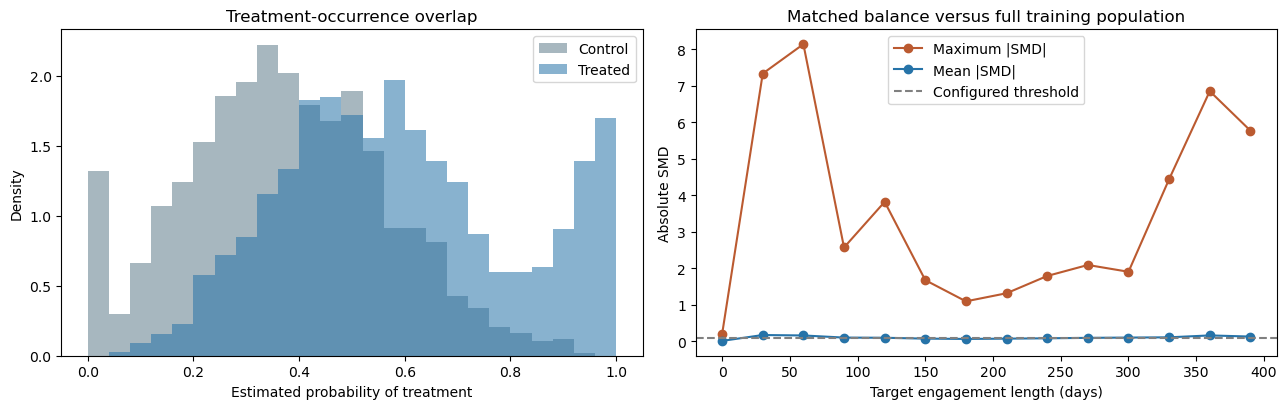

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for treatment, label, color in [(0, 'Control', '#607d8b'), (1, 'Treated', '#2673a8')]:
    axes[0].hist(p_treated[received == treatment], bins=np.linspace(0, 1, 26),
                 density=True, alpha=0.55, label=label, color=color)
axes[0].set(xlabel='Estimated probability of treatment', ylabel='Density', title='Treatment-occurrence overlap')
axes[0].legend()
axes[1].plot(diagnostics['target_days'], diagnostics['max_abs_smd'], 'o-', color='#bb5a30', label='Maximum |SMD|')
axes[1].plot(diagnostics['target_days'], diagnostics['mean_abs_smd'], 'o-', color='#2673a8', label='Mean |SMD|')
axes[1].axhline(GPS_CONFIG['maximum_abs_smd'], ls='--', color='gray', label='Configured threshold')
axes[1].set(xlabel='Target engagement length (days)', ylabel='Absolute SMD', title='Matched balance versus full training population')
axes[1].legend()
fig.tight_layout()
plt.show()

### Estimate the population curve and benefit versus zero

The unsmoothed estimate at each grid point averages the matched donors' observed outcomes across
all training templates. The smooth positive curve uses each donor's total positive-dose reuse count
as its regression weight, following the CausalGPS pseudo-population construction. The zero reference
is estimated separately from its zero matches and is **never included in the positive-dose smoother**.
The same reference is subtracted at every positive dose.

The fixed smoothing bandwidth is 30 days by default (a singleton bandwidth candidate, so no outcome
bandwidth search). Open markers and dashed lines identify failed screening checks. Estimates with
no donor window remain missing and cannot be bridged by smoothing. Out-of-range local-linear risks
are flagged instead of clipped. The line joins the configured grid points; no curve is interpolated
between the zero point mass and the first positive dose.

In [27]:
# Analysis stage: outcomes enter only after the matching design is complete.
observed_y = gps_train['ed_event_90d'].to_numpy(dtype=float)
reference_risk = float(observed_y[matches_by_dose[0.0]].mean())
positive_targets = np.asarray([day for day in target_days if day > 0 and float(day) in matches_by_dose])
if not len(positive_targets):
    raise ValueError('No positive targets have donors. Review the configured grid and caliper.')
smooth_positive_risk = gaussian_local_linear(
    dose, observed_y, positive_counter_weight, positive_targets,
    GPS_CONFIG['smoothing_bandwidth_days'],
)
smoothed_lookup = dict(zip(positive_targets, smooth_positive_risk))
zero_pass = bool(diagnostics.loc[diagnostics['target_days'].eq(0), 'basic_checks_pass'].iloc[0])
curve_rows = []
for day in target_days:
    info = diagnostics.loc[diagnostics['target_days'].eq(day)].iloc[0]
    matched = matches_by_dose.get(float(day))
    raw_risk = float(observed_y[matched].mean()) if matched is not None else np.nan
    smooth_risk = reference_risk if day == 0 else smoothed_lookup.get(day, np.nan)
    in_bounds = bool(np.isfinite(smooth_risk) and 0 <= smooth_risk <= 1)
    curve_rows.append({
        'engagement_days': day, 'target_rows': n_templates,
        'matched_ed_risk': raw_risk, 'smoothed_ed_risk': smooth_risk,
        'reference_zero_ed_risk': reference_risk,
        'raw_benefit_pp': 100 * (reference_risk - raw_risk),
        'benefit_pp': 100 * (reference_risk - smooth_risk),
        'zero_reference_checks_pass': zero_pass,
        'smoothed_risk_in_bounds': in_bounds,
        'basic_checks_pass': bool(info['basic_checks_pass']) and zero_pass and in_bounds,
        'flags': str(info['flags']) + ('; zero reference flagged' if not zero_pass else '')
                 + ('; invalid/unbounded smooth risk' if not in_bounds else ''),
    })
benefit_curve = pd.DataFrame(curve_rows)
gps_train['zero_counter_weight'] = zero_counter_weight
gps_train['positive_counter_weight'] = positive_counter_weight
# Audit donor outcomes without representing them as personalized predicted benefits.
donor_y_by_id = pd.Series(observed_y, index=row_ids)
match_table['donor_observed_ed_event'] = match_table['donor_analysis_row_id'].map(donor_y_by_id)
assert np.isfinite(benefit_curve.loc[benefit_curve['engagement_days'].eq(0), 'benefit_pp']).all()
assert benefit_curve.loc[benefit_curve['engagement_days'].eq(0), 'benefit_pp'].iloc[0] == 0.0
display(benefit_curve.round(4))
print(f'Zero-exposure reference ED risk: {reference_risk:.2%}.')
print(f"Positive-dose contrasts passing basic checks: {benefit_curve.loc[benefit_curve['engagement_days'] > 0, 'basic_checks_pass'].sum()} / {len(target_days) - 1}.")
if not zero_pass:
    print('The zero-exposure reference failed balance/support checks; all benefit contrasts remain exploratory.')

,engagement_days,target_rows,matched_ed_risk,smoothed_ed_risk,reference_zero_ed_risk,raw_benefit_pp,benefit_pp,zero_reference_checks_pass,smoothed_risk_in_bounds,basic_checks_pass,flags
0,0.0,4452,0.2725,0.2725,0.2725,0.0000,0.0000,False,True,False,covariate imbalance; zero reference flagged
1,30.0,4452,0.0009,-0.0068,0.2725,27.1563,27.9218,False,False,False,few candidate donors; low member ESS; covariat...
2,60.0,4452,0.0002,0.0282,0.2725,27.2237,24.4234,False,True,False,low member ESS; covariate imbalance; zero refe...
3,90.0,4452,0.0946,0.0862,0.2725,17.7898,18.6273,False,True,False,low member ESS; covariate imbalance; zero refe...
4,120.0,4452,0.1739,0.1372,0.2725,9.8607,13.5229,False,True,False,low member ESS; covariate imbalance; zero refe...
5,150.0,4452,0.1217,0.1733,0.2725,15.0719,9.9186,False,True,False,low member ESS; covariate imbalance; zero refe...
6,180.0,4452,0.2722,0.2084,0.2725,0.0225,6.4086,False,True,False,covariate imbalance; zero reference flagged
7,210.0,4452,0.2078,0.2248,0.2725,6.4690,4.7707,False,True,False,low member ESS; covariate imbalance; zero refe...
8,240.0,4452,0.1593,0.2669,0.2725,11.3208,0.5537,False,True,False,low member ESS; covariate imbalance; zero refe...
9,270.0,4452,0.5094,0.3212,0.2725,-23.6972,-4.8691,False,True,False,low member ESS; covariate imbalance; zero refe...


Zero-exposure reference ED risk: 27.25%.
Positive-dose contrasts passing basic checks: 0 / 13.
The zero-exposure reference failed balance/support checks; all benefit contrasts remain exploratory.


Saved curve, matching audit, diagnostics, and configuration to: /home/sagemaker-user/prism_repo/Outputs/Dosage_Funds/Python


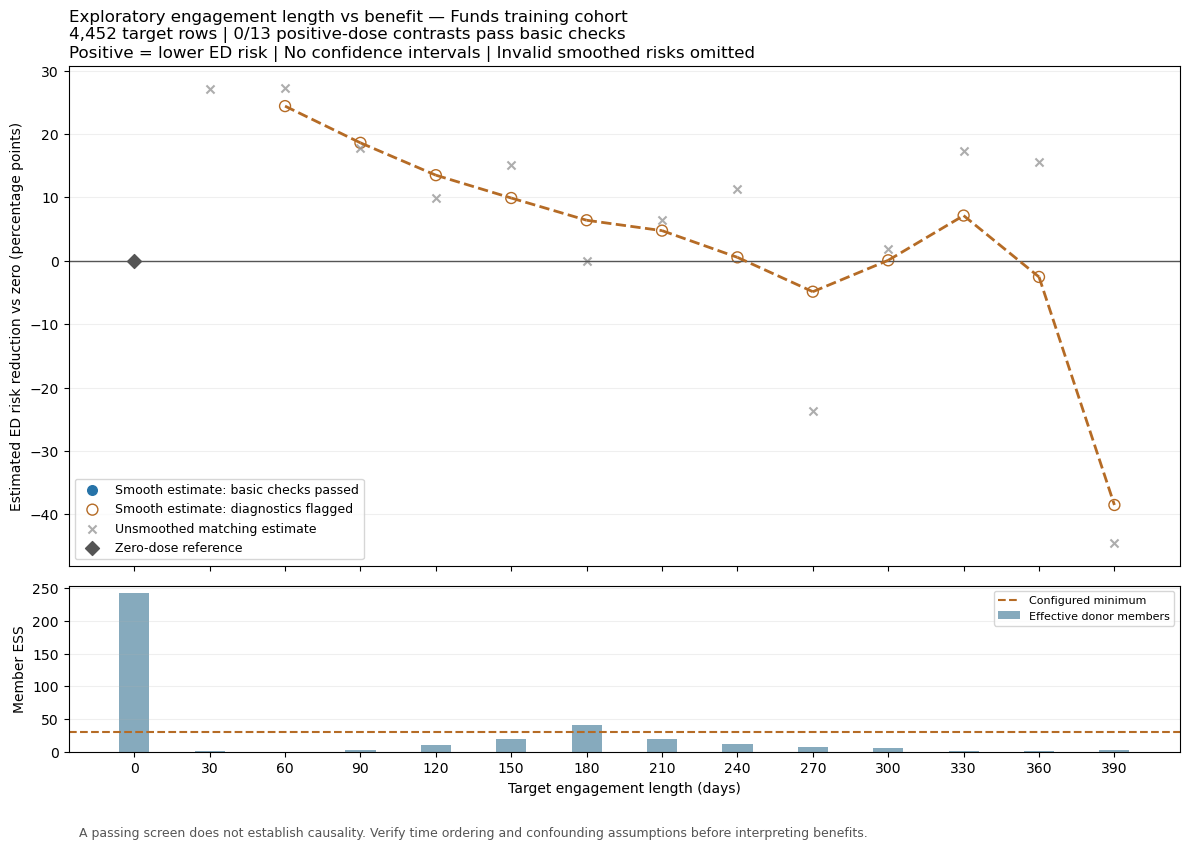

In [28]:
# Save reproducible audit outputs in a dedicated directory; no prior model outputs are overwritten.
if GPS_CONFIG['write_outputs']:
    GPS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    analysis_columns = [
        'analysis_row_id', 'member_id', 'received_treatment', 'raw_engagement_length',
        'analysis_dose_days', 'dose_status', 'ed_event_90d', 'outcome_missing_filled_zero',
        'p_treated', 'predicted_log_days', 'gps_at_observed_exposure',
        'zero_counter_weight', 'positive_counter_weight',
    ]
    exports = {
        'engagement_gps_analysis_rows.csv': gps_train[analysis_columns],
        'engagement_gps_exposure_audit.csv': exposure_audit,
        'engagement_gps_matches.csv': match_table,
        'engagement_gps_diagnostics.csv': diagnostics,
        'engagement_gps_balance_by_dose.csv': balance_by_dose,
        'engagement_length_benefit_curve.csv': benefit_curve,
    }
    for filename, table in exports.items():
        table.to_csv(GPS_OUTPUT_DIR / filename, index=False)
    run_metadata = {
        'config': GPS_CONFIG, 'target_training_rows': n_templates,
        'zero_donors': int(zero_donor.sum()), 'positive_donors': int(positive_donor.sum()),
        'positive_log_residual_sd': duration_residual_sd,
        'baseline_columns': baseline_cols, 'encoded_features': gps_covariates.columns.tolist(),
        'training_numeric_medians': training_medians.to_dict(),
        'reference_causalgps_commit': '283eb3299b81fb91fd56e6f426c2a1d0f699bf67',
        'estimator': 'two-part extension of CausalGPS matching; not an official R-equivalent two-part estimator',
        'inference': 'point estimates only; no bootstrap confidence intervals',
    }
    (GPS_OUTPUT_DIR / 'engagement_gps_run_metadata.json').write_text(
        json.dumps(run_metadata, indent=2), encoding='utf-8'
    )
    print('Saved curve, matching audit, diagnostics, and configuration to:', GPS_OUTPUT_DIR)

# Final visible result. Never smooth across the point mass at zero.
fig, axes = plt.subplots(2, 1, figsize=(12, 8.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
positive_curve = benefit_curve.loc[benefit_curve['engagement_days'] > 0]
x = positive_curve['engagement_days'].to_numpy()
# Retain unbounded estimates in the CSV, but suppress impossible risks in the graph.
b = positive_curve['benefit_pp'].where(positive_curve['smoothed_risk_in_bounds']).to_numpy()
passed = positive_curve['basic_checks_pass'].to_numpy(dtype=bool)
axes[0].axhline(0, color='#555555', lw=1)
# Segment-by-segment styling avoids connecting passing points across failed targets.
for k in range(len(x) - 1):
    if np.isfinite(b[k:k+2]).all():
        ok = passed[k] and passed[k+1]
        axes[0].plot(x[k:k+2], b[k:k+2], color='#2673a8' if ok else '#b56b25',
                     ls='-' if ok else '--', lw=2)
axes[0].scatter(x[passed], b[passed], color='#2673a8', s=48, label='Smooth estimate: basic checks passed')
axes[0].scatter(x[~passed], b[~passed], facecolors='none', edgecolors='#b56b25',
                s=62, label='Smooth estimate: diagnostics flagged')
axes[0].scatter(x, positive_curve['raw_benefit_pp'], color='#999999', marker='x',
                s=34, alpha=0.8, label='Unsmoothed matching estimate')
axes[0].scatter([0], [0], marker='D', color='#555555', s=50, label='Zero-dose reference')
axes[0].set_ylabel('Estimated ED risk reduction vs zero (percentage points)')
title_prefix = 'Exploratory ' if not GPS_CONFIG['outcome_window_confirmed_after_exposure'] else ''
axes[0].set_title(
    f'{title_prefix}engagement length vs benefit — Funds training cohort\n'
    f'{n_templates:,} target rows | {int(passed.sum())}/{len(passed)} positive-dose contrasts pass basic checks\n'
    'Positive = lower ED risk | No confidence intervals | Invalid smoothed risks omitted',
    loc='left', fontsize=12,
)
axes[0].grid(axis='y', alpha=0.2)
axes[0].legend(loc='best', fontsize=9)
axes[1].bar(diagnostics['target_days'], diagnostics['member_ess'],
            width=12, color='#86aabd', label='Effective donor members')
axes[1].axhline(GPS_CONFIG['minimum_member_ess'], color='#b56b25', ls='--',
                label='Configured minimum')
axes[1].set(xlabel='Target engagement length (days)', ylabel='Member ESS')
axes[1].set_xticks(target_days)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.2)
fig.text(0.07, 0.01,
         'A passing screen does not establish causality. Verify time ordering and confounding assumptions before interpreting benefits.',
         fontsize=9, color='#555555')
fig.tight_layout(rect=[0, 0.04, 1, 1])
if GPS_CONFIG['write_outputs']:
    fig.savefig(GPS_OUTPUT_DIR / 'engagement_length_vs_benefit.png', dpi=170, bbox_inches='tight')
plt.show()

Poor matching and excessive donor reuse
- At several engagement levels, very few unique donors provide the comparisons, and some donors are reused disproportionately. This makes estimates depend heavily on a small number of patients.
- Potential fixes: Obtain more independent patients across the engagement range, especially at sparsely represented durations. Reassess the matching settings and limit reporting to exposure levels with adequate support. More data helps only if it supplies the patient profiles and doses currently missing.

Substantial covariate imbalance
- The matched groups differ from the target training population on baseline characteristics. The untreated reference group also fails the balance check, affecting every benefit comparison.
- Potential fixes: Identify the covariates driving imbalance, improve the exposure-assignment models, and jointly tune the exposure window and GPS matching weight using balance diagnostics—not the resulting benefit curve. Restricting the target population may help, but changes whom the results apply to.

Exposure and outcome periods overlap
- The 90-day ED outcome window starts 90 days after engagement begins, but many engagement durations extend into or beyond that window. Some exposure therefore occurs during or after the outcomes being analyzed.
- Potential fixes: Define engagement during a clearly specified period that ends before outcome follow-up begins, with a comparable starting point for untreated patients. Studying longer engagement durations may require later outcome windows or a longitudinal causal approach. Simply capping recorded durations at 90 days does not automatically resolve the problem.

The exposure window involves a trade-off
- The current 60-day-wide window allows donors within ±30 days of each target. This can blur differences between neighboring engagement levels.
- Potential fixes: Compare alternative window widths. Narrower windows improve dose specificity but may worsen donor scarcity and reuse; wider windows increase available donors but compare less similar durations. Choose settings based on support and balance.

The curve differs from expectations, but this is not itself an analytical flaw
- We expected increasing benefit with diminishing returns. Instead, the current curve generally shows greater estimated benefit at shorter durations. Because the diagnostics fail, we cannot determine whether this reflects a real relationship or problems in the analysis.
- Potential fixes: Resolve timing and matching problems first, assess sensitivity to smoothing, and add appropriate uncertainty estimates. Do not select settings simply because they produce the expected shape.

Additional data-quality and uncertainty limitations
- Missing outcomes were treated as zero, repeated member records remain in the analysis, and the graph has no confidence intervals.
- Potential fixes: Verify that missing outcomes genuinely mean no ED event, clarify whether the analysis unit should be a patient or an engagement episode, and account for repeated members and matching when estimating uncertainty.